# Shortcut Discovery — Dyna-Q vs Dyna-Q+

**Why the previous experiment was inconclusive:** when a corridor *closes*, both algorithms immediately experience the bounce and update their model — the change is trivially detectable.

**The real Dyna-Q+ advantage** only appears when the environment *improves* (a shortcut *opens*):
once epsilon has decayed to nearly zero, Dyna-Q has stopped exploring and **never discovers** the new route.
Dyna-Q+'s τ bonus keeps growing for unvisited shortcut states until it eventually **pulls the agent there through planning**, even without any random exploration.

---

**Environment:** 13×13 grid, vertical wall at col 6 (rows 1–11).
Two long detours exist via row 0 and row 12 (24 steps each).
At episode 10 000 the wall at `(6, 6)` is **removed**, opening a direct 12-step corridor.
By that point epsilon has decayed to its minimum (0.01) — Dyna-Q is nearly greedy
and never deviates from the long route it already knows.

In [9]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from helpers.env import SlipperyGridWorld
from helpers.viz import plot_env, plot_policy, plot_value_heatmap, greedy_policy_from_V
from helpers.rl import value_iteration
from helpers.dynaq import dyna_q, dyna_q_plus

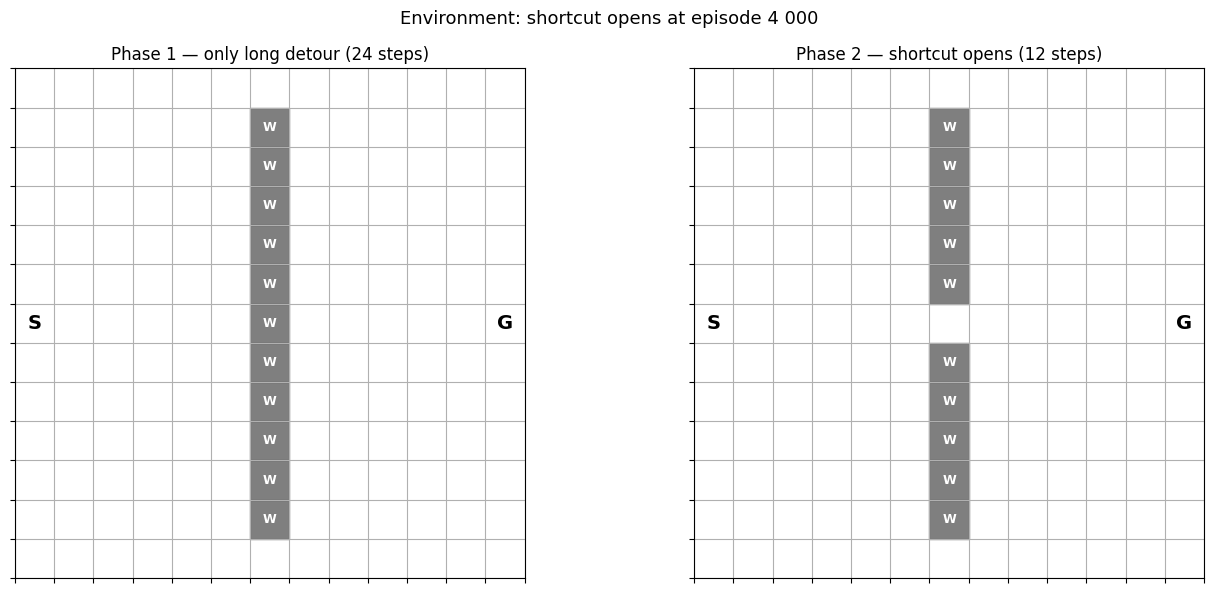

In [ ]:
NUM_ROWS, NUM_COLS = 13, 13
START, GOAL       = (6, 0), (6, 12)
SHORTCUT_CELL     = (6, 6)

# Phase 1: full wall — NO corridor. Agent must detour via row 0 or row 12.
WALLS_PHASE1 = {(r, 6) for r in range(1, 12)}
# Phase 2: shortcut opens — remove (6,6) from walls.
WALLS_PHASE2 = WALLS_PHASE1 - {SHORTCUT_CELL}

SLIP_PROB   = 0.05
STEP_REWARD = -1.0
GOAL_REWARD = 30.0
MAX_STEPS   = 200
GAMMA       = 0.99
SEED        = 42

N_EPISODES = 20000  
CHANGE_AT  = 10000  # shortcut opens here; epsilon is at minimum by this point

def make_env(walls):
    return SlipperyGridWorld(
        rows=NUM_ROWS, cols=NUM_COLS,
        start=START, goal=GOAL,
        slip_prob=SLIP_PROB,
        step_reward=STEP_REWARD,
        goal_reward=GOAL_REWARD,
        wall_fields=walls,
        max_steps=MAX_STEPS,
        seed=SEED,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_env(make_env(WALLS_PHASE1), title="Phase 1 — only long detour (24 steps)",  ax=axes[0])
plot_env(make_env(WALLS_PHASE2), title="Phase 2 — shortcut opens (12 steps)",     ax=axes[1])
plt.suptitle("Environment: shortcut opens at episode 10 000", fontsize=13)
plt.tight_layout(); plt.savefig("sc_envs.png", dpi=150); plt.show()

## Optimal policies (Value Iteration reference)

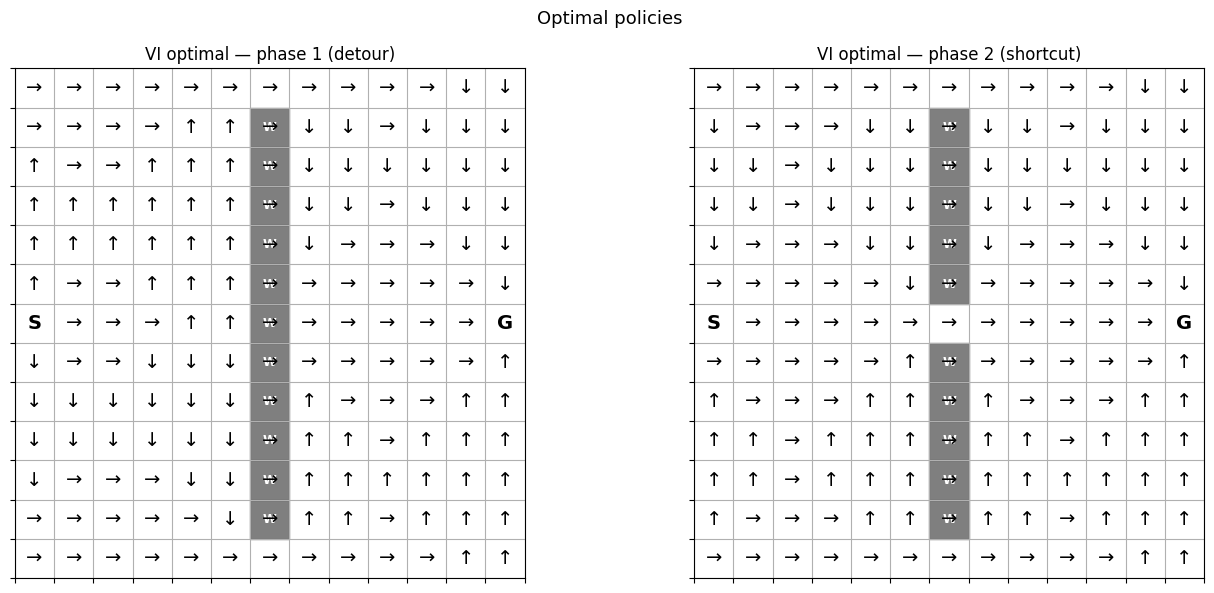

Theoretical discounted return — detour: 2.14   shortcut: 15.23


In [11]:
env_p1 = make_env(WALLS_PHASE1)
env_p2 = make_env(WALLS_PHASE2)
V_p1, _ = value_iteration(env_p1, max_iterations=500, gamma=GAMMA, threshold=1e-6)
V_p2, _ = value_iteration(env_p2, max_iterations=500, gamma=GAMMA, threshold=1e-6)
pi_p1 = greedy_policy_from_V(V_p1, env_p1, GAMMA)
pi_p2 = greedy_policy_from_V(V_p2, env_p2, GAMMA)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_policy(env_p1, pi_p1, title="VI optimal — phase 1 (detour)",   ax=axes[0])
plot_policy(env_p2, pi_p2, title="VI optimal — phase 2 (shortcut)", ax=axes[1])
plt.suptitle("Optimal policies", fontsize=13)
plt.tight_layout(); plt.savefig("sc_vi.png", dpi=150); plt.show()

m1 = dict(p1_return=float(np.sum([GAMMA**t * STEP_REWARD for t in range(24)]) + GAMMA**24 * GOAL_REWARD),
          p2_return=float(np.sum([GAMMA**t * STEP_REWARD for t in range(12)]) + GAMMA**12 * GOAL_REWARD))
print(f"Theoretical discounted return — detour: {m1['p1_return']:.2f}   shortcut: {m1['p2_return']:.2f}")

## Training
Epsilon decays from 0.9 to 0.01 over the first 10 000 episodes (phase 1).
By the time the shortcut opens both agents are nearly greedy — the only way to
discover the shortcut is through Dyna-Q+'s planning bonus.

In [12]:
ALPHA         = 0.2
EPSILON       = 0.9
EPSILON_MIN   = 0.01
EPSILON_DECAY = 0.9995   # epsilon ≈ 0.01 at episode 10 000
N_PLANNING    = 5
KAPPA         = 0.005

open_shortcut = {CHANGE_AT: lambda env: env.remove_wall(SHORTCUT_CELL)}

td_kwargs = dict(
    n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY, n_planning_steps=N_PLANNING, seed=SEED,
)

env_dq  = make_env(WALLS_PHASE1)
Q_dq,  rewards_dq  = dyna_q(
    env_dq,  **td_kwargs, env_changes=open_shortcut)

env_dqp = make_env(WALLS_PHASE1)
Q_dqp, rewards_dqp = dyna_q_plus(
    env_dqp, **td_kwargs, kappa=KAPPA, env_changes=open_shortcut)

print("Training complete.")

Training complete.


## Convergence curves

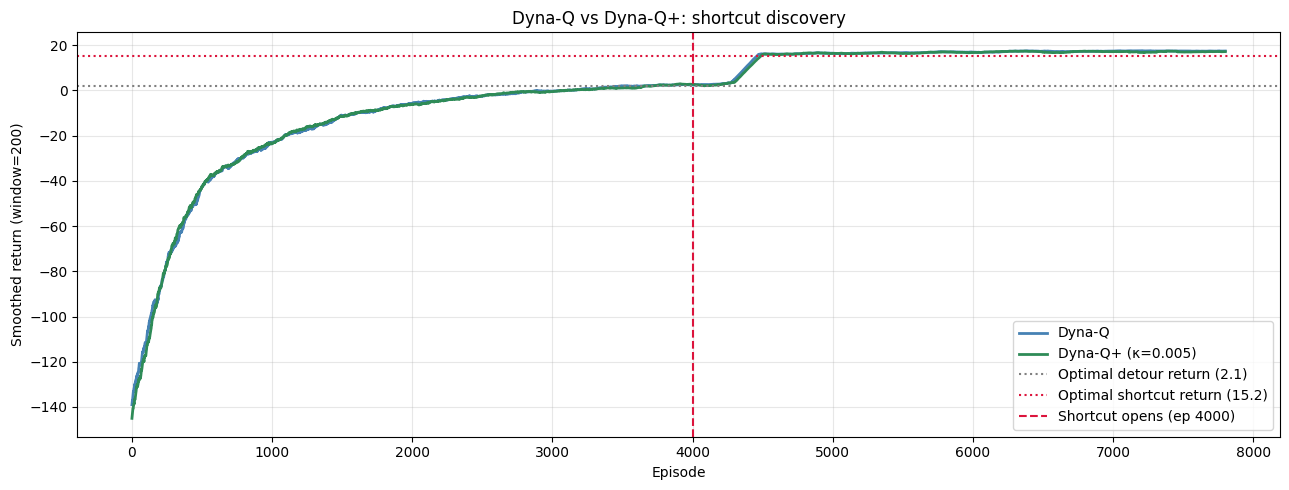

In [13]:
def smooth(x, w=200):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(figsize=(13, 5))
for rewards, label, color in [
    (rewards_dq,  "Dyna-Q",               "steelblue"),
    (rewards_dqp, f"Dyna-Q+ (κ={KAPPA})", "seagreen"),
]:
    ax.plot(smooth(rewards), label=label, color=color, linewidth=2)

# Reference lines
ax.axhline(m1['p1_return'], color="gray",   linestyle=":",  linewidth=1.5,
           label=f"Optimal detour return ({m1['p1_return']:.1f})")
ax.axhline(m1['p2_return'], color="crimson", linestyle=":",  linewidth=1.5,
           label=f"Optimal shortcut return ({m1['p2_return']:.1f})")
ax.axvline(CHANGE_AT, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Shortcut opens (ep {CHANGE_AT})")

ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed return (window=200)")
ax.set_title("Dyna-Q vs Dyna-Q+: shortcut discovery")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("sc_convergence.png", dpi=150); plt.show()

## Phase 2 zoom — how quickly does each algorithm reach the shortcut return?

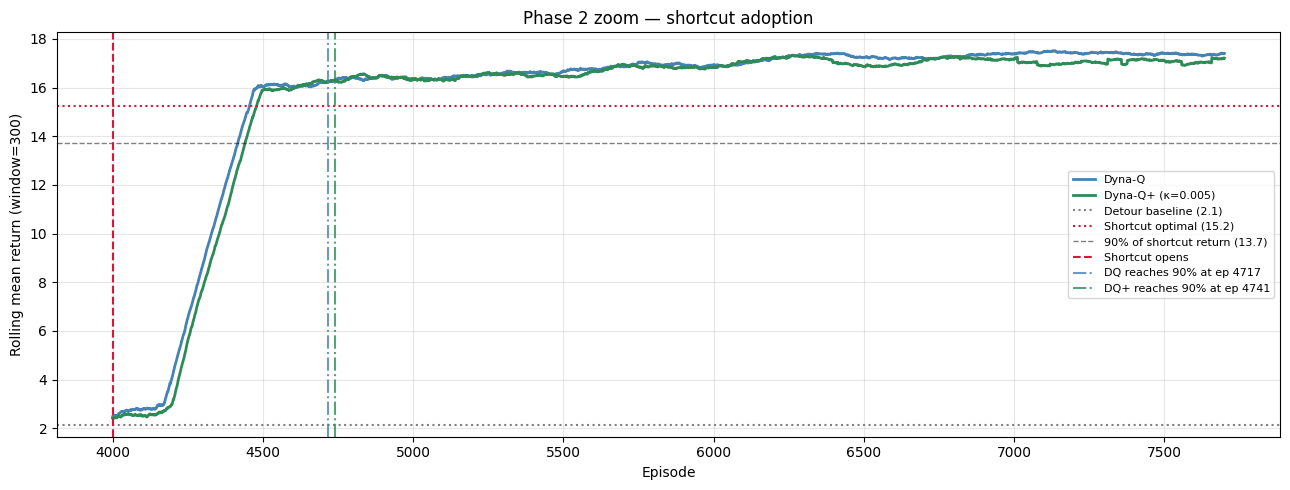

Episodes after shortcut opens to reach 90% of optimal:
  Dyna-Q : 717
  Dyna-Q+: 741


In [14]:
W = 300
p2_dq  = np.convolve(rewards_dq[CHANGE_AT:],  np.ones(W)/W, mode="valid")
p2_dqp = np.convolve(rewards_dqp[CHANGE_AT:], np.ones(W)/W, mode="valid")

target = m1['p2_return'] * 0.90
def first_hit(arr, t):
    hits = np.where(arr >= t)[0]
    return int(hits[0]) + W if len(hits) else None

hit_dq  = first_hit(p2_dq,  target)
hit_dqp = first_hit(p2_dqp, target)

ep2 = np.arange(CHANGE_AT, CHANGE_AT + len(p2_dq))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ep2, p2_dq,  label="Dyna-Q",               color="steelblue", linewidth=2)
ax.plot(np.arange(CHANGE_AT, CHANGE_AT + len(p2_dqp)),
        p2_dqp, label=f"Dyna-Q+ (κ={KAPPA})",      color="seagreen",  linewidth=2)
ax.axhline(m1['p1_return'], color="gray",   linestyle=":", linewidth=1.5,
           label=f"Detour baseline ({m1['p1_return']:.1f})")
ax.axhline(m1['p2_return'], color="crimson", linestyle=":", linewidth=1.5,
           label=f"Shortcut optimal ({m1['p2_return']:.1f})")
ax.axhline(target, color="black", linestyle="--", linewidth=1, alpha=0.5,
           label=f"90% of shortcut return ({target:.1f})")
ax.axvline(CHANGE_AT, color="crimson", linestyle="--", linewidth=1.5, label="Shortcut opens")
for hit, color, name in [(hit_dq,  "steelblue", "DQ"), (hit_dqp, "seagreen", "DQ+")]:
    if hit is not None:
        ax.axvline(CHANGE_AT + hit, color=color, linestyle="-.", alpha=0.8,
                   label=f"{name} reaches 90% at ep {CHANGE_AT + hit}")

ax.set_xlabel("Episode")
ax.set_ylabel("Rolling mean return (window=300)")
ax.set_title("Phase 2 zoom — shortcut adoption")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("sc_phase2.png", dpi=150); plt.show()

print(f"Episodes after shortcut opens to reach 90% of optimal:")
print(f"  Dyna-Q : {hit_dq}")
print(f"  Dyna-Q+: {hit_dqp}")

## Final learned policies

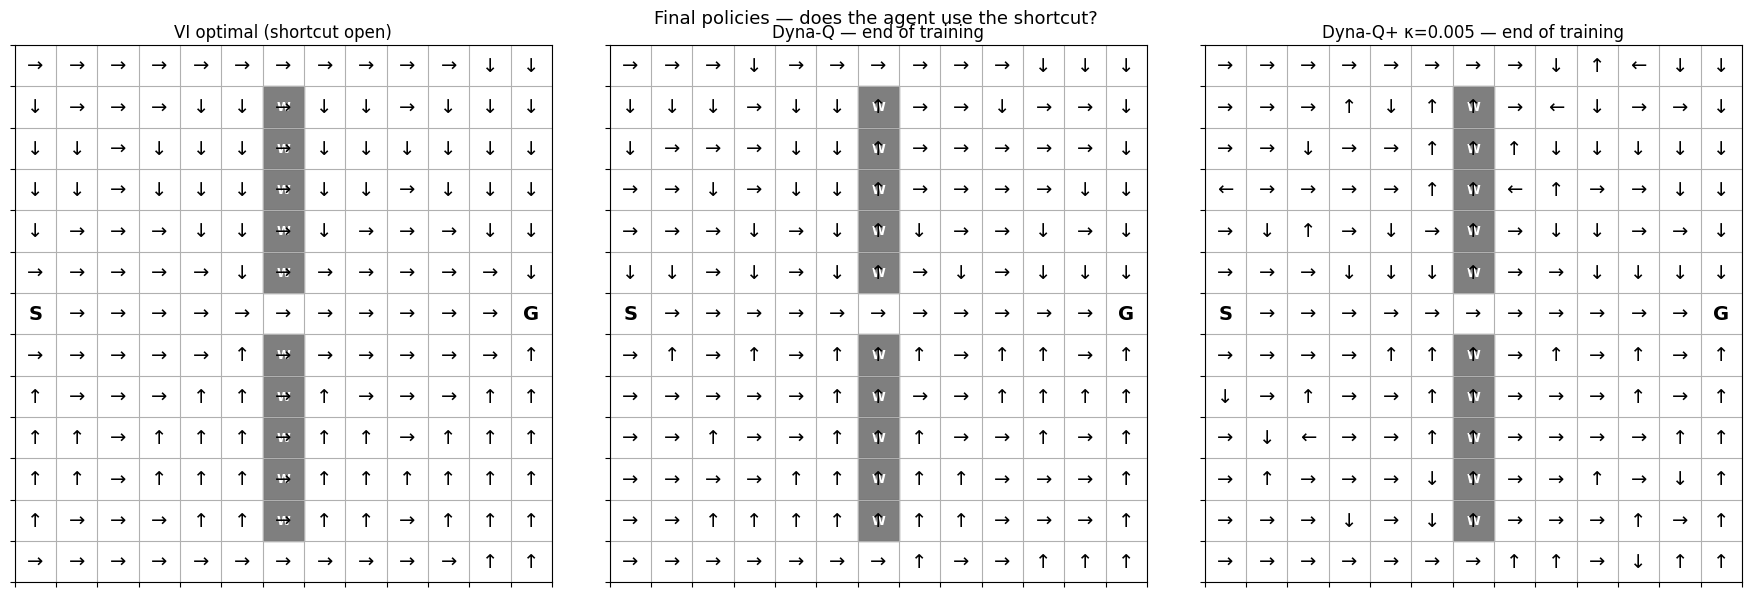

In [15]:
pi_dq  = np.argmax(Q_dq,  axis=1).astype(float)
pi_dqp = np.argmax(Q_dqp, axis=1).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_policy(env_p2,  pi_p2,  title="VI optimal (shortcut open)",       ax=axes[0])
plot_policy(env_dq,  pi_dq,  title="Dyna-Q — end of training",         ax=axes[1])
plot_policy(env_dqp, pi_dqp, title=f"Dyna-Q+ κ={KAPPA} — end of training", ax=axes[2])
plt.suptitle("Final policies — does the agent use the shortcut?", fontsize=13)
plt.tight_layout(); plt.savefig("sc_policies.png", dpi=150); plt.show()

## κ ablation — exploration bonus sensitivity

In [16]:
kappa_values = [0.0, 0.001, 0.005, 0.01, 0.05]
kappa_rewards = {}
for k in kappa_values:
    e = make_env(WALLS_PHASE1)
    fn = dyna_q if k == 0.0 else dyna_q_plus
    kw = {} if k == 0.0 else {"kappa": k}
    _, r = fn(e, **td_kwargs, **kw, env_changes=open_shortcut)
    kappa_rewards[k] = r

fig, ax = plt.subplots(figsize=(13, 5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(kappa_values)))
for (k, rews), color in zip(kappa_rewards.items(), cmap):
    label = f"κ={k}" + (" (= Dyna-Q)" if k == 0.0 else "")
    ax.plot(smooth(rews), label=label, color=color, linewidth=1.8)
ax.axhline(m1['p2_return'], color="crimson", linestyle=":",  linewidth=1.5,
           label=f"Shortcut optimal ({m1['p2_return']:.1f})")
ax.axvline(CHANGE_AT, color="crimson", linestyle="--", linewidth=1.5,
           label="Shortcut opens")
ax.set_xlabel("Episode"); ax.set_ylabel("Smoothed return (window=200)")
ax.set_title("Dyna-Q+: effect of κ on shortcut discovery")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("sc_kappa.png", dpi=150); plt.show()

KeyboardInterrupt: 

## Conclusions

### Why this experiment reveals the true difference
When a corridor *closes* both algorithms detect it immediately through real experience (they bounce and get a wrong reward). When a shortcut *opens*, **neither** algorithm gets any signal — the old long route still works perfectly. Only an agent that actively re-explores unvisited states will ever discover the improvement.

### Phase 1 — both converge to the detour
Both algorithms learn the only available 24-step route. Over 10 000 episodes epsilon decays to its minimum (0.01), making the policy nearly deterministic. States along the shortcut path (particularly the right side of the wall) are never visited.

### Phase 2 — shortcut opens
- **Dyna-Q**: epsilon = 0.01 → only 1% random actions. The agent follows the known detour almost every episode and never wanders to the shortcut passage. Its return stays near the detour baseline.
- **Dyna-Q+**: τ for all shortcut-side states has been growing since the last visit (often the full 10 000-episode phase). The exploration bonus κ√τ is large enough to raise Q-values of shortcut actions above the greedy detour actions **in planning**, even before a single real shortcut episode. Once the agent is pushed by the bonus to try the passage, the model updates and value propagates rapidly.

### κ sensitivity
- Too small (0.001): bonus too weak relative to τ — barely distinguishable from Dyna-Q.
- Moderate (0.005–0.01): clear fast discovery with no phase-1 instability.
- Too large (0.05): destabilises Q-values during phase 1 (unnecessary exploration of already-known transitions hurts convergence).